# Day 26 — Boosting Algorithms

**Dataset:** `sklearn.datasets.fetch_covtype` (Forest Cover Type — multiclass classification, 54 features, 7 classes)

## Agenda
1. What is Boosting? (theory)
2. AdaBoost (theory + hyperparameters + pros/cons + use cases)
3. Gradient Boosting (theory + hyperparameters + pros/cons + use cases)
4. XGBoost (theory + hyperparameters + pros/cons + use cases)
5. LightGBM (theory + hyperparameters + pros/cons + use cases)
6. CatBoost (theory + hyperparameters + pros/cons + use cases)
7. Load & minimally preprocess `fetch_covtype`
8. Baselines: Decision Tree & Random Forest
9. Hands-on: AdaBoost vs Gradient Boosting
10. Model comparison (accuracy, F1, timing, feature importance)
11. Practice Questions

> **Note:** XGBoost, LightGBM, and CatBoost are covered in **theory only** here (no training) to keep this notebook lightweight and dependency-free. The hands-on demo uses `AdaBoostClassifier` and `GradientBoostingClassifier` from scikit-learn, compared against `DecisionTreeClassifier` and `RandomForestClassifier`. A commented-out "optional" section at the end shows how you'd plug XGBoost/LightGBM/CatBoost in if those libraries are installed.


## 1. What is Boosting?

**Boosting** is an **ensemble learning** technique that combines many **weak learners** (models that are only slightly better than random guessing — typically shallow decision trees / "stumps") into one **strong learner**, by training them **sequentially**.

### Core idea
- Train a weak model on the data.
- Look at where it made mistakes.
- Train the *next* model to focus more on those mistakes (either by re-weighting misclassified samples, or by fitting the *residual error* of the previous model).
- Repeat for many rounds, then combine all models via a **weighted vote / weighted sum**.

### Boosting vs Bagging (Random Forest)

| Aspect | Bagging (e.g., Random Forest) | Boosting (e.g., AdaBoost, GBM) |
|---|---|---|
| Training | Parallel, independent trees | Sequential, each tree depends on the previous |
| Goal | Reduce **variance** | Reduce **bias** (and variance, indirectly) |
| Base learners | Usually deep/full trees | Usually shallow trees ("weak learners") |
| Data sampling | Bootstrap samples (random subsets w/ replacement) | Full data, but re-weighted / residual-based |
| Overfitting risk | Lower | Higher (needs careful tuning: learning rate, n_estimators, depth) |
| Speed | Easily parallelizable | Inherently sequential (slower to train, except histogram-based variants) |

### Families of Boosting
1. **Adaptive Boosting (AdaBoost)** — re-weights misclassified samples.
2. **Gradient Boosting (GBM)** — fits new learners to the **negative gradient** (residuals) of a loss function.
3. **Modern Gradient Boosting frameworks** — XGBoost, LightGBM, CatBoost: highly optimized, regularized, scalable implementations of gradient boosting with engineering improvements (histogram binning, GPU support, leaf-wise growth, native categorical handling, etc.)


## 2. AdaBoost (Adaptive Boosting)

Proposed by Freund & Schapire (1997). It is the original, foundational boosting algorithm.

### How it works
1. Initialize equal weights for all training samples: $w_i = 1/N$.
2. For $m = 1$ to $M$ rounds:
   - Train a weak learner (commonly a **decision stump** — a tree of depth 1) on the weighted data.
   - Compute the weighted error rate $\varepsilon_m$ of this learner.
   - Compute the learner's "say" (weight in the final vote): $\alpha_m = \frac{1}{2}\ln\left(\frac{1-\varepsilon_m}{\varepsilon_m}\right)$.
   - **Increase** the weights of misclassified samples and **decrease** weights of correctly classified samples, then normalize.
3. Final prediction = weighted majority vote (classification) or weighted sum (regression) of all weak learners, weighted by $\alpha_m$.

Samples that are hard to classify get progressively more attention from later learners.

### Key Hyperparameters (`sklearn.ensemble.AdaBoostClassifier`)
| Hyperparameter | Meaning |
|---|---|
| `estimator` (base learner) | Weak learner to boost (default: depth-1 decision tree) |
| `n_estimators` | Number of boosting rounds (weak learners) |
| `learning_rate` | Shrinks the contribution ($\alpha_m$) of each learner; trade-off with `n_estimators` |
| `algorithm` / `loss` | Boosting variant (e.g., `SAMME` for classification) |
| `random_state` | Reproducibility |

### Advantages
- Simple, easy to implement, few hyperparameters to tune.
- Often improves accuracy of weak learners significantly with little tuning.
- Less prone to overfitting than a single deep tree (since it uses many weak stumps).
- Works for both classification and regression.

### Disadvantages
- **Very sensitive to noisy data and outliers** — misclassified noisy points get up-weighted repeatedly and can dominate training.
- Sequential nature makes it slower to train than bagging methods; not easily parallelizable.
- Performance depends heavily on the choice/quality of the weak learner.
- Tends to underperform modern gradient boosting frameworks on large, complex tabular datasets.

### Typical Use Cases
- Face detection (the classic Viola–Jones detector used a boosting cascade).
- Text/spam classification with simple base learners.
- Any small-to-medium tabular problem where a fast, low-tuning-effort boosted model is wanted.


## 3. Gradient Boosting (GBM)

Proposed by Friedman (2001). Generalizes boosting as **gradient descent in function space**.

### How it works
1. Start with an initial simple prediction (e.g., the mean for regression, log-odds for classification).
2. For $m = 1$ to $M$ rounds:
   - Compute the **negative gradient** (pseudo-residuals) of the loss function w.r.t. the current predictions — for squared-error loss this is just $y_i - \hat{y}_i$.
   - Fit a new weak learner (usually a shallow regression tree) to predict these pseudo-residuals.
   - Add the new learner's predictions to the ensemble, scaled by a **learning rate** ($\hat{y} \mathrel{+}= \eta \cdot h_m(x)$).
3. Final model = sum of the initial prediction + all the (scaled) weak learners.

Unlike AdaBoost (which re-weights samples), Gradient Boosting directly fits the **errors/residuals** of the previous ensemble using gradient descent, which lets it optimize *any differentiable loss function* (MSE, log-loss, Huber, etc.)

### Key Hyperparameters (`sklearn.ensemble.GradientBoostingClassifier`)
| Hyperparameter | Meaning |
|---|---|
| `n_estimators` | Number of boosting stages (trees) |
| `learning_rate` | Shrinks contribution of each tree; smaller = need more trees but generalizes better |
| `max_depth` | Depth of each individual tree (controls weak learner complexity) |
| `subsample` | Fraction of samples used per tree (< 1.0 → "Stochastic Gradient Boosting", reduces variance) |
| `max_features` | Number of features considered per split |
| `min_samples_split` / `min_samples_leaf` | Regularization — minimum samples to split/at a leaf |
| `loss` | Loss function to optimize (`log_loss`, `exponential`, etc.) |

### Advantages
- Usually higher accuracy than AdaBoost / single trees / even Random Forest on tabular data.
- Flexible — can optimize any differentiable loss function (regression, classification, ranking).
- Built-in feature importance.
- Regularization options (`subsample`, `max_depth`, `learning_rate`) give strong control over overfitting.

### Disadvantages
- Slower to train than Random Forest (sequential; each tree depends on the last).
- More hyperparameters to tune, more prone to overfitting if not tuned carefully.
- Sensitive to outliers (still fitting residuals of a loss like squared error).
- Less scalable to very large datasets than optimized frameworks like XGBoost/LightGBM (plain sklearn GBM has no histogram binning).

### Typical Use Cases
- Tabular data competitions (baseline before moving to XGBoost/LightGBM).
- Risk scoring / credit scoring, churn prediction, click-through-rate prediction.
- Ranking problems (learning-to-rank), when combined with ranking losses.


## 4. XGBoost (Extreme Gradient Boosting)

Created by Tianqi Chen (2014). An **optimized, regularized, and scalable** implementation of gradient boosting that became the dominant algorithm in tabular ML competitions (e.g., Kaggle).

### What it adds on top of plain Gradient Boosting
- **Regularized objective**: adds L1/L2 regularization terms on leaf weights directly into the loss function (reduces overfitting).
- **Second-order optimization**: uses both first and second derivatives (gradient *and* Hessian) of the loss for more accurate tree splits (Newton boosting).
- **Approximate / histogram-based split finding** for speed on large data.
- **Built-in handling of missing values** (learns a default split direction).
- **Column & row subsampling** (like Random Forest) to reduce variance and speed up training.
- **Parallelized tree construction** (parallel over features/columns while building a single tree — not parallel over trees, since boosting is sequential).
- Supports GPU training, early stopping, cross-validation utilities.

### Key Hyperparameters
| Hyperparameter | Meaning |
|---|---|
| `n_estimators` | Number of boosting rounds |
| `learning_rate` (`eta`) | Shrinkage per round |
| `max_depth` | Max tree depth |
| `subsample` | Row sampling ratio per tree |
| `colsample_bytree` | Column sampling ratio per tree |
| `gamma` | Minimum loss reduction required to make a further split (regularization) |
| `reg_alpha`, `reg_lambda` | L1 / L2 regularization on leaf weights |
| `min_child_weight` | Minimum sum of instance weight (Hessian) needed in a child — controls tree complexity |
| `early_stopping_rounds` | Stop training if validation metric doesn't improve |

### Advantages
- State-of-the-art accuracy on structured/tabular data; historically dominant on Kaggle.
- Fast, due to histogram/approximate split-finding and parallel column processing.
- Strong built-in regularization → less prone to overfitting than plain GBM.
- Handles missing values natively; supports GPU acceleration.

### Disadvantages
- Many hyperparameters — tuning can be time-consuming.
- Still sequential across boosting rounds → training slower than bagging methods for very large data (though much faster than plain sklearn GBM).
- Can overfit on small/noisy datasets if not regularized properly.
- Less intuitive/interpretable than a single decision tree.

### Typical Use Cases
- Kaggle / structured data competitions.
- Fraud detection, credit risk, insurance claim prediction.
- Any large tabular dataset needing high accuracy with manageable training time.


## 5. LightGBM (Light Gradient Boosting Machine)

Developed by Microsoft (2017). Designed for **speed and scalability on very large datasets**.

### Key innovations
- **Leaf-wise (best-first) tree growth** instead of level-wise: it grows the leaf with the largest loss reduction first, rather than growing all leaves at a given depth. This produces deeper, more accurate trees per boosting round but requires careful depth limiting to avoid overfitting.
- **Histogram-based split finding**: buckets continuous features into discrete bins, dramatically speeding up split search and reducing memory use.
- **Gradient-based One-Side Sampling (GOSS)**: keeps all samples with large gradients (poorly-fit samples) and randomly samples from the rest — focuses computation where it matters.
- **Exclusive Feature Bundling (EFB)**: bundles mutually-exclusive sparse features together to reduce dimensionality (helps with high-dimensional sparse/categorical data).
- Native support for categorical features (no need to one-hot encode).

### Key Hyperparameters
| Hyperparameter | Meaning |
|---|---|
| `n_estimators` | Number of boosting rounds |
| `learning_rate` | Shrinkage per round |
| `num_leaves` | Max leaves per tree (main complexity control for leaf-wise growth; typically < `2^max_depth`) |
| `max_depth` | Optional depth cap to control overfitting |
| `min_data_in_leaf` | Minimum samples per leaf (regularization) |
| `feature_fraction` | Column sampling ratio (like `colsample_bytree`) |
| `bagging_fraction` / `bagging_freq` | Row sampling ratio / frequency |
| `lambda_l1`, `lambda_l2` | Regularization |

### Advantages
- Extremely fast training, low memory usage — best choice for very large datasets (millions of rows).
- Often matches or exceeds XGBoost accuracy.
- Native categorical feature support (no encoding needed).
- Good default choice when speed and scale matter.

### Disadvantages
- Leaf-wise growth can overfit on small datasets if `num_leaves`/depth isn't controlled.
- More sensitive to hyperparameters than level-wise methods on small data.
- Historically less robust than XGBoost on very small/noisy datasets (though the gap has narrowed).

### Typical Use Cases
- Large-scale tabular data (millions+ rows), where XGBoost training time becomes a bottleneck.
- Recommendation systems, ad click prediction, search ranking at industrial scale.
- Datasets with many categorical features.


## 6. CatBoost (Categorical Boosting)

Developed by Yandex (2017). Designed to handle **categorical features natively and robustly**, and to reduce a subtle bias present in other GBM implementations called **prediction shift / target leakage**.

### Key innovations
- **Native categorical feature handling** via *ordered target statistics*: encodes categories using target statistics computed only from "past" data in a random permutation (avoids leakage from using the current row's own target).
- **Ordered Boosting**: builds the model using a permutation-based scheme so that the residual for a given sample is computed using a model that never saw that sample's target — reduces the prediction-shift bias common in classic gradient boosting.
- **Symmetric (oblivious) trees**: all nodes at the same depth use the same split condition, making trees faster to evaluate and less prone to overfitting; also enables very fast inference (production-friendly).
- Strong out-of-the-box results with fewer hyperparameters to tune than XGBoost/LightGBM.

### Key Hyperparameters
| Hyperparameter | Meaning |
|---|---|
| `iterations` (`n_estimators`) | Number of boosting rounds |
| `learning_rate` | Shrinkage per round |
| `depth` | Tree depth (symmetric trees, so this controls both complexity and speed) |
| `l2_leaf_reg` | L2 regularization on leaf values |
| `cat_features` | Indices of categorical columns (handled natively) |
| `border_count` | Number of splits considered for numeric features (histogram bins) |
| `early_stopping_rounds` | Stop when validation metric stops improving |

### Advantages
- Best-in-class handling of categorical data — often no preprocessing/encoding needed at all.
- Reduces overfitting/target leakage via ordered boosting — strong results with default parameters.
- Symmetric trees → very fast prediction/inference, good for production use.
- Good built-in support for GPU training.

### Disadvantages
- Training can be slower than LightGBM on very large purely-numeric datasets.
- Symmetric tree constraint can slightly limit flexibility vs. leaf-wise/level-wise trees in some cases.
- Smaller community/ecosystem historically vs. XGBoost.

### Typical Use Cases
- Tabular datasets with many categorical features (e.g., customer/marketing data, e-commerce).
- Production systems needing fast inference with minimal preprocessing effort.
- Competitions/problems where you want strong results with little hyperparameter tuning.

---

### Quick comparison

| | AdaBoost | Gradient Boosting | XGBoost | LightGBM | CatBoost |
|---|---|---|---|---|---|
| Core idea | Re-weight samples | Fit residuals (gradient descent) | Regularized 2nd-order GB | Leaf-wise + histogram GB | Ordered boosting + symmetric trees |
| Speed | Moderate | Slow (unoptimized) | Fast | Fastest (large data) | Fast, very fast inference |
| Categorical handling | Manual encoding | Manual encoding | Manual encoding (or limited) | Native | Best-in-class native |
| Overfitting risk | High (on noisy data) | Moderate–High | Moderate (regularized) | Moderate (tune `num_leaves`) | Low (ordered boosting) |
| Typical use | Small/simple data | Baseline GBM | Kaggle / general tabular | Very large tabular data | Categorical-heavy tabular data |


## 7. Load & Minimally Preprocess the Data — `fetch_covtype`

`fetch_covtype` is a real-world **multiclass classification** dataset: predicting one of **7 forest cover types** from 54 cartographic variables (elevation, slope, soil type, wilderness area, etc.). It has **581,012 rows**, so for a reasonably fast demo we'll take a **stratified subsample**.

Since all 54 features are already numeric (10 continuous + 44 binary one-hot columns for soil type / wilderness area), **minimal preprocessing** is needed — just a train/test split and (optionally) scaling for the tree-based models, which don't actually require scaling but we include a `StandardScaler` step to show best practice.


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (7, 5)

In [2]:
# Fetch the Forest Covertype dataset (downloads once, then cached locally)
covtype = fetch_covtype(as_frame=True)
X_full = covtype.data
y_full = covtype.target

print("Full dataset shape:", X_full.shape)
print("Classes (cover types):", sorted(y_full.unique()))
X_full.head()

Full dataset shape: (581012, 54)
Classes (cover types): [1, 2, 3, 4, 5, 6, 7]


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# The full dataset has ~581k rows. For a fast, illustrative comparison of
# boosting algorithms we take a stratified subsample (~20,000 rows).
# Feel free to increase SAMPLE_SIZE if you have more time/compute.
SAMPLE_SIZE = 20_000

X_sample, _, y_sample, _ = train_test_split(
    X_full, y_full,
    train_size=SAMPLE_SIZE,
    stratify=y_full,
    random_state=RANDOM_STATE,
)

print("Subsampled shape:", X_sample.shape)
y_sample.value_counts(normalize=True).sort_index()

Subsampled shape: (20000, 54)


Cover_Type
1    0.36460
2    0.48760
3    0.06155
4    0.00470
5    0.01635
6    0.02990
7    0.03530
Name: proportion, dtype: float64

In [4]:
# Minimal preprocessing:
# 1) Train/test split (stratified, since classes are imbalanced)
# 2) Standard scaling of features (not strictly required for trees, but good practice
#    and keeps the pipeline reusable if you swap in a non-tree model later)

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample,
    test_size=0.2,
    stratify=y_sample,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (16000, 54)  Test shape: (4000, 54)


## 8. Baseline Models: Decision Tree & Random Forest

Before evaluating boosting methods, we train two baselines:
- A single **Decision Tree** (high variance, prone to overfitting).
- A **Random Forest** (bagging ensemble — reduces variance by averaging many independent trees).


In [5]:
results = {}  # will store {"model_name": {"accuracy":..., "f1":..., "train_time":..., "predict_time":...}}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_te)
    predict_time = time.time() - t0

    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred, average="macro")

    results[name] = {
        "accuracy": acc,
        "f1_macro": f1,
        "train_time_s": train_time,
        "predict_time_s": predict_time,
    }

    print(f"--- {name} ---")
    print(f"Accuracy      : {acc:.4f}")
    print(f"F1 (macro)    : {f1:.4f}")
    print(f"Train time    : {train_time:.2f}s")
    print(f"Predict time  : {predict_time:.2f}s")
    print(classification_report(y_te, y_pred, zero_division=0))

    return model, y_pred

In [6]:
dt = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt_model, dt_pred = evaluate_model(
    "Decision Tree", dt, X_train_scaled, y_train, X_test_scaled, y_test
)

--- Decision Tree ---
Accuracy      : 0.7605
F1 (macro)    : 0.5944
Train time    : 1.09s
Predict time  : 0.17s
              precision    recall  f1-score   support

           1       0.76      0.73      0.75      1458
           2       0.78      0.84      0.80      1951
           3       0.71      0.79      0.75       246
           4       0.43      0.47      0.45        19
           5       0.76      0.20      0.32        65
           6       0.58      0.29      0.39       120
           7       0.74      0.67      0.70       141

    accuracy                           0.76      4000
   macro avg       0.68      0.57      0.59      4000
weighted avg       0.76      0.76      0.75      4000



In [7]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=15, n_jobs=-1, random_state=RANDOM_STATE
)
rf_model, rf_pred = evaluate_model(
    "Random Forest", rf, X_train_scaled, y_train, X_test_scaled, y_test
)

--- Random Forest ---
Accuracy      : 0.7945
F1 (macro)    : 0.6157
Train time    : 5.44s
Predict time  : 0.22s
              precision    recall  f1-score   support

           1       0.81      0.74      0.77      1458
           2       0.79      0.88      0.83      1951
           3       0.74      0.91      0.82       246
           4       1.00      0.26      0.42        19
           5       0.88      0.11      0.19        65
           6       0.80      0.38      0.51       120
           7       0.91      0.66      0.77       141

    accuracy                           0.79      4000
   macro avg       0.85      0.56      0.62      4000
weighted avg       0.80      0.79      0.79      4000



## 9. Hands-on: AdaBoost

`AdaBoostClassifier` natively supports **binary** classification with `SAMME`; for our **multiclass** (7-class) problem scikit-learn's `SAMME` algorithm handles multiclass directly by generalizing the weighting scheme. We use shallow decision stumps (`max_depth=1`) as the weak learner, per the classic AdaBoost recipe.


In [8]:
ada_base = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)  # decision stump
ada = AdaBoostClassifier(
    estimator=ada_base,
    n_estimators=200,
    learning_rate=0.5,
    algorithm="SAMME",
    random_state=RANDOM_STATE,
)

ada_model, ada_pred = evaluate_model(
    "AdaBoost", ada, X_train_scaled, y_train, X_test_scaled, y_test
)

--- AdaBoost ---
Accuracy      : 0.6667
F1 (macro)    : 0.3413
Train time    : 6.39s
Predict time  : 0.36s
              precision    recall  f1-score   support

           1       0.64      0.64      0.64      1458
           2       0.70      0.78      0.74      1951
           3       0.66      0.65      0.65       246
           4       0.00      0.00      0.00        19
           5       0.00      0.00      0.00        65
           6       0.38      0.33      0.35       120
           7       0.00      0.00      0.00       141

    accuracy                           0.67      4000
   macro avg       0.34      0.34      0.34      4000
weighted avg       0.63      0.67      0.65      4000



## 10. Hands-on: Gradient Boosting

`GradientBoostingClassifier` fits successive trees to the pseudo-residuals of the multiclass log-loss. Because it's sequential and not histogram-optimized, we keep `n_estimators` moderate to keep runtime reasonable on the 20k-row sample; scale up if you have more time.


In [9]:
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,           # stochastic gradient boosting -> reduces variance
    random_state=RANDOM_STATE,
)

gb_model, gb_pred = evaluate_model(
    "Gradient Boosting", gb, X_train_scaled, y_train, X_test_scaled, y_test
)

--- Gradient Boosting ---
Accuracy      : 0.7825
F1 (macro)    : 0.6615
Train time    : 63.25s
Predict time  : 0.09s
              precision    recall  f1-score   support

           1       0.78      0.75      0.77      1458
           2       0.79      0.85      0.82      1951
           3       0.76      0.80      0.78       246
           4       0.50      0.68      0.58        19
           5       0.67      0.28      0.39        65
           6       0.62      0.44      0.51       120
           7       0.84      0.73      0.78       141

    accuracy                           0.78      4000
   macro avg       0.71      0.65      0.66      4000
weighted avg       0.78      0.78      0.78      4000



## 11. Model Comparison

Compare all four models — **Decision Tree, Random Forest, AdaBoost, Gradient Boosting** — on accuracy, macro-F1, and training/prediction time.


In [10]:
results_df = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
results_df

,accuracy,f1_macro,train_time_s,predict_time_s
Random Forest,0.79450,0.615689,5.440829,0.224031
Gradient Boosting,0.78250,0.661524,63.245147,0.093740
Decision Tree,0.76050,0.594447,1.087211,0.171862
AdaBoost,0.66675,0.341333,6.386520,0.359355


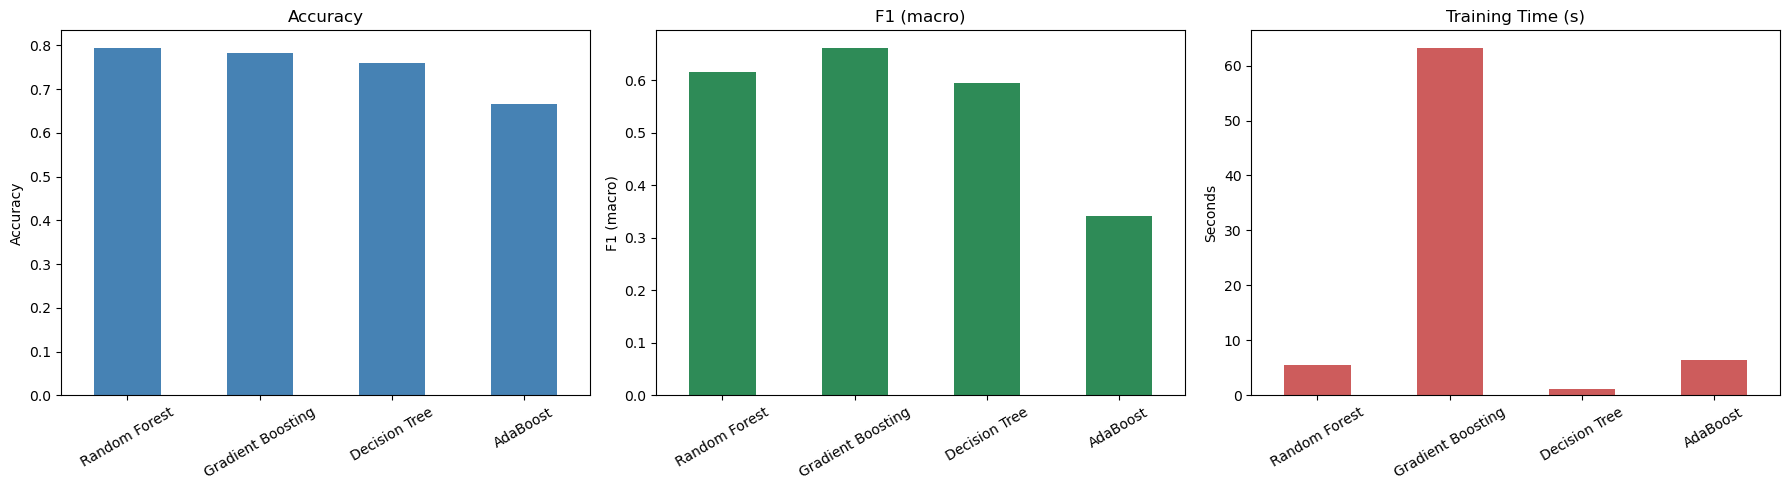

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_df["accuracy"].plot(kind="bar", ax=axes[0], color="steelblue", title="Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].tick_params(axis="x", rotation=30)

results_df["f1_macro"].plot(kind="bar", ax=axes[1], color="seagreen", title="F1 (macro)")
axes[1].set_ylabel("F1 (macro)")
axes[1].tick_params(axis="x", rotation=30)

results_df["train_time_s"].plot(kind="bar", ax=axes[2], color="indianred", title="Training Time (s)")
axes[2].set_ylabel("Seconds")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

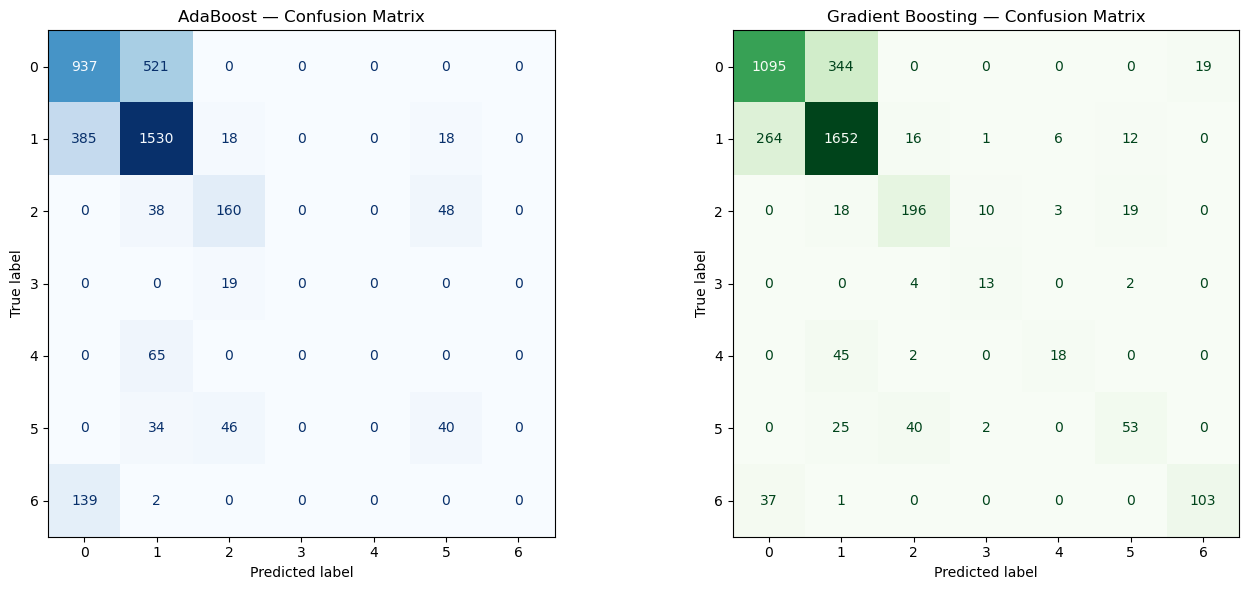

In [12]:
# Confusion matrices side-by-side for the two boosting models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay(confusion_matrix(y_test, ada_pred)).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("AdaBoost — Confusion Matrix")

ConfusionMatrixDisplay(confusion_matrix(y_test, gb_pred)).plot(
    ax=axes[1], colorbar=False, cmap="Greens"
)
axes[1].set_title("Gradient Boosting — Confusion Matrix")

plt.tight_layout()
plt.show()

### Feature Importance: AdaBoost vs Gradient Boosting vs Random Forest

Tree-based ensembles expose `feature_importances_`, letting us see which cartographic variables drive the cover-type prediction.


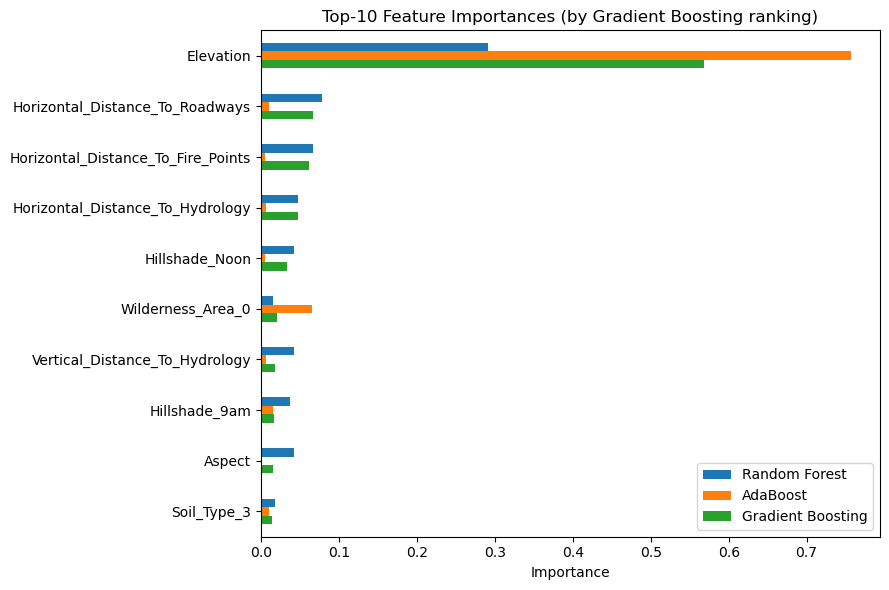

In [13]:
feature_names = X_train.columns

importances_df = pd.DataFrame({
    "Random Forest": rf_model.feature_importances_,
    "AdaBoost": ada_model.feature_importances_,
    "Gradient Boosting": gb_model.feature_importances_,
}, index=feature_names)

top_features = importances_df["Gradient Boosting"].sort_values(ascending=False).head(10).index
importances_df.loc[top_features].plot(kind="barh", figsize=(9, 6))
plt.title("Top-10 Feature Importances (by Gradient Boosting ranking)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Discussion — what do we observe?

- **Decision Tree**: fastest to train, but typically the weakest generalization (highest variance) — a single tree overfits the training data.
- **Random Forest**: averaging many deep, independent trees reduces variance substantially and usually beats a single tree by a wide margin; training is parallelizable (`n_jobs=-1`) so it's fast despite having many trees.
- **AdaBoost**: with weak stumps (`max_depth=1`), each individual learner is very weak, so AdaBoost typically needs many rounds and tends to underperform Gradient Boosting / Random Forest on this dataset — it was designed more for binary problems and simple weak learners than for large multiclass tabular problems like this one.
- **Gradient Boosting**: fitting residuals with slightly deeper trees (`max_depth=3`) and a moderate learning rate usually gives the best or near-best accuracy of the four, at the cost of the slowest training time (sequential, no histogram optimization in plain sklearn).
- In practice, for a dataset of this size, **XGBoost / LightGBM / CatBoost** (see theory sections above) would train much faster than sklearn's `GradientBoostingClassifier` while matching or improving on its accuracy — that's precisely why they replaced plain GBM as the industry standard for tabular data.

> Exact numbers will vary by run/subsample size — re-run the notebook and inspect `results_df` for your own numbers.


## 12. (Optional) Plugging in XGBoost / LightGBM / CatBoost

If you have `xgboost`, `lightgbm`, and/or `catboost` installed (`pip install xgboost lightgbm catboost`), you can drop them into the exact same `evaluate_model` harness used above. The cell below is provided as a **template only** (commented out) — uncomment and run it if you'd like to extend the comparison.


In [16]:
from xgboost import XGBClassifier
# XGBoost expects class labels starting at 0
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", random_state=RANDOM_STATE, eval_metric="mlogloss"
)
xgb_model, xgb_pred = evaluate_model(
    "XGBoost", xgb, X_train_scaled, y_train_xgb, X_test_scaled, y_test_xgb
)

--- XGBoost ---
Accuracy      : 0.8290
F1 (macro)    : 0.7423
Train time    : 7.83s
Predict time  : 0.14s
              precision    recall  f1-score   support

           0       0.84      0.79      0.81      1458
           1       0.83      0.89      0.86      1951
           2       0.78      0.90      0.84       246
           3       1.00      0.58      0.73        19
           4       0.88      0.32      0.47        65
           5       0.75      0.56      0.64       120
           6       0.93      0.77      0.84       141

    accuracy                           0.83      4000
   macro avg       0.86      0.69      0.74      4000
weighted avg       0.83      0.83      0.83      4000



In [21]:
pip install catboost

  Obtaining dependency information for catboost from https://files.pythonhosted.org/packages/a9/af/36048fdd08eca7876716176c30acf0e7ff1dfb1f53d0b93a021537e26601/catboost-1.2.10-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for graphviz from https://files.pythonhosted.org/packages/91/4c/e0ce1ef95d4000ebc1c11801f9b944fa5910ecc15b5e351865763d8657f8/graphviz-0.21-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/100.2 MB 653.6 kB/s eta 0:02:34
   ---------------------------------------- 0.2/100.2 MB 1.2 MB/s eta 0:01:27
   ---------------------------------------- 0.3/100.2 MB 1.7 MB/s eta 0:00:59
   ---------------------------------------- 0.4/100.2 MB 1.6 MB/s eta 0:01:02
   ---------------------------------------- 0.4/100.2 MB 1.6 MB/s eta 0:01:02
   ---------------------------------------- 0.7/100.2 M

In [22]:
from catboost import CatBoostClassifier
cat = CatBoostClassifier(
    iterations=300, learning_rate=0.1, depth=6,
    verbose=False, random_state=RANDOM_STATE
)
cat_model, cat_pred = evaluate_model(
    "CatBoost", cat, X_train, y_train, X_test, y_test  # CatBoost doesn't need scaling
)

--- CatBoost ---
Accuracy      : 0.7977
F1 (macro)    : 0.6585
Train time    : 11.50s
Predict time  : 0.03s
              precision    recall  f1-score   support

           1       0.80      0.76      0.78      1458
           2       0.80      0.87      0.83      1951
           3       0.74      0.87      0.80       246
           4       0.73      0.42      0.53        19
           5       0.81      0.20      0.32        65
           6       0.74      0.42      0.54       120
           7       0.90      0.73      0.80       141

    accuracy                           0.80      4000
   macro avg       0.79      0.61      0.66      4000
weighted avg       0.80      0.80      0.79      4000



## 13. Hyperparameter Cheat Sheet (Summary)

| Algorithm | Most Important Hyperparameters |
|---|---|
| **AdaBoost** | `n_estimators`, `learning_rate`, `estimator` (base learner) |
| **Gradient Boosting** | `n_estimators`, `learning_rate`, `max_depth`, `subsample` |
| **XGBoost** | `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `gamma`, `reg_alpha`/`reg_lambda`, `min_child_weight` |
| **LightGBM** | `n_estimators`, `learning_rate`, `num_leaves`, `max_depth`, `min_data_in_leaf`, `feature_fraction`, `bagging_fraction` |
| **CatBoost** | `iterations`, `learning_rate`, `depth`, `l2_leaf_reg`, `cat_features`, `border_count` |

**General tuning principle for all boosting methods:** there's a trade-off between `learning_rate` and `n_estimators`/`iterations` — a smaller learning rate needs more boosting rounds but usually generalizes better. Always tune them together (or use early stopping on a validation set).


## 14. Practice Questions

**Conceptual**
1. Explain in your own words the difference between **bagging** and **boosting**. Why does boosting reduce bias while bagging mainly reduces variance?
2. Walk through the AdaBoost algorithm step by step. What happens to the weight of a sample that is misclassified in round $m$?
3. In Gradient Boosting, what exactly does each new tree learn to predict? How does this differ from what AdaBoost's weak learners learn?
4. Why is Gradient Boosting described as "gradient descent in function space"? What role does the negative gradient of the loss function play?
5. List three engineering improvements XGBoost introduces over classic Gradient Boosting, and explain how each helps either speed or generalization.
6. What is "leaf-wise" tree growth in LightGBM, and why can it be both an advantage (accuracy) and a risk (overfitting)?
7. What problem does CatBoost's "ordered boosting" solve? Why is it particularly important when a dataset has many categorical features?
8. Why are decision stumps (`max_depth=1`) commonly used as the weak learner in AdaBoost, rather than deep trees?
9. Why is AdaBoost more sensitive to noisy data/outliers than Gradient Boosting or Random Forest?
10. Explain the trade-off between `learning_rate` and `n_estimators` in boosting. What happens if `learning_rate` is very high with few estimators? Very low with few estimators?

**Applied / Hands-on**
11. Re-run the notebook with the full `fetch_covtype` dataset (remove the subsampling step). How do the relative rankings of the four models change, if at all?
12. Increase `n_estimators` for AdaBoost (e.g., to 500) and re-evaluate. Does accuracy keep improving, plateau, or degrade? Why?
13. Try `max_depth=2` or `max_depth=3` for the AdaBoost base estimator instead of a stump. How does that affect accuracy and training time?
14. Tune `learning_rate` and `max_depth` for `GradientBoostingClassifier` using a small grid search. What combination gives the best macro-F1 on a validation split?
15. Install `xgboost`, `lightgbm`, and/or `catboost`, uncomment the optional section, and compare their accuracy and training time against the sklearn Gradient Boosting model on the same subsample. What differences do you observe?
16. Plot **training accuracy** vs. **test accuracy** for Gradient Boosting as you increase `n_estimators` from 10 to 300. At what point does the model start to overfit?
17. For Random Forest and Gradient Boosting, compare the `feature_importances_`. Are the top features similar? Why might boosting and bagging methods rank feature importance somewhat differently?
18. This is a **multiclass** problem (7 classes) with class imbalance (some cover types are much rarer than others). Investigate the per-class precision/recall in the classification reports above — which classes are hardest for each model, and why might that be?
19. Try using `class_weight="balanced"` (Random Forest / Decision Tree) or adjusting `sample_weight` (AdaBoost / Gradient Boosting) to handle class imbalance. Does macro-F1 improve?
20. Time-box a mini experiment: fix a total training-time budget (e.g., 60 seconds) for each algorithm. Which algorithm achieves the best accuracy within that fixed time budget?
